In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

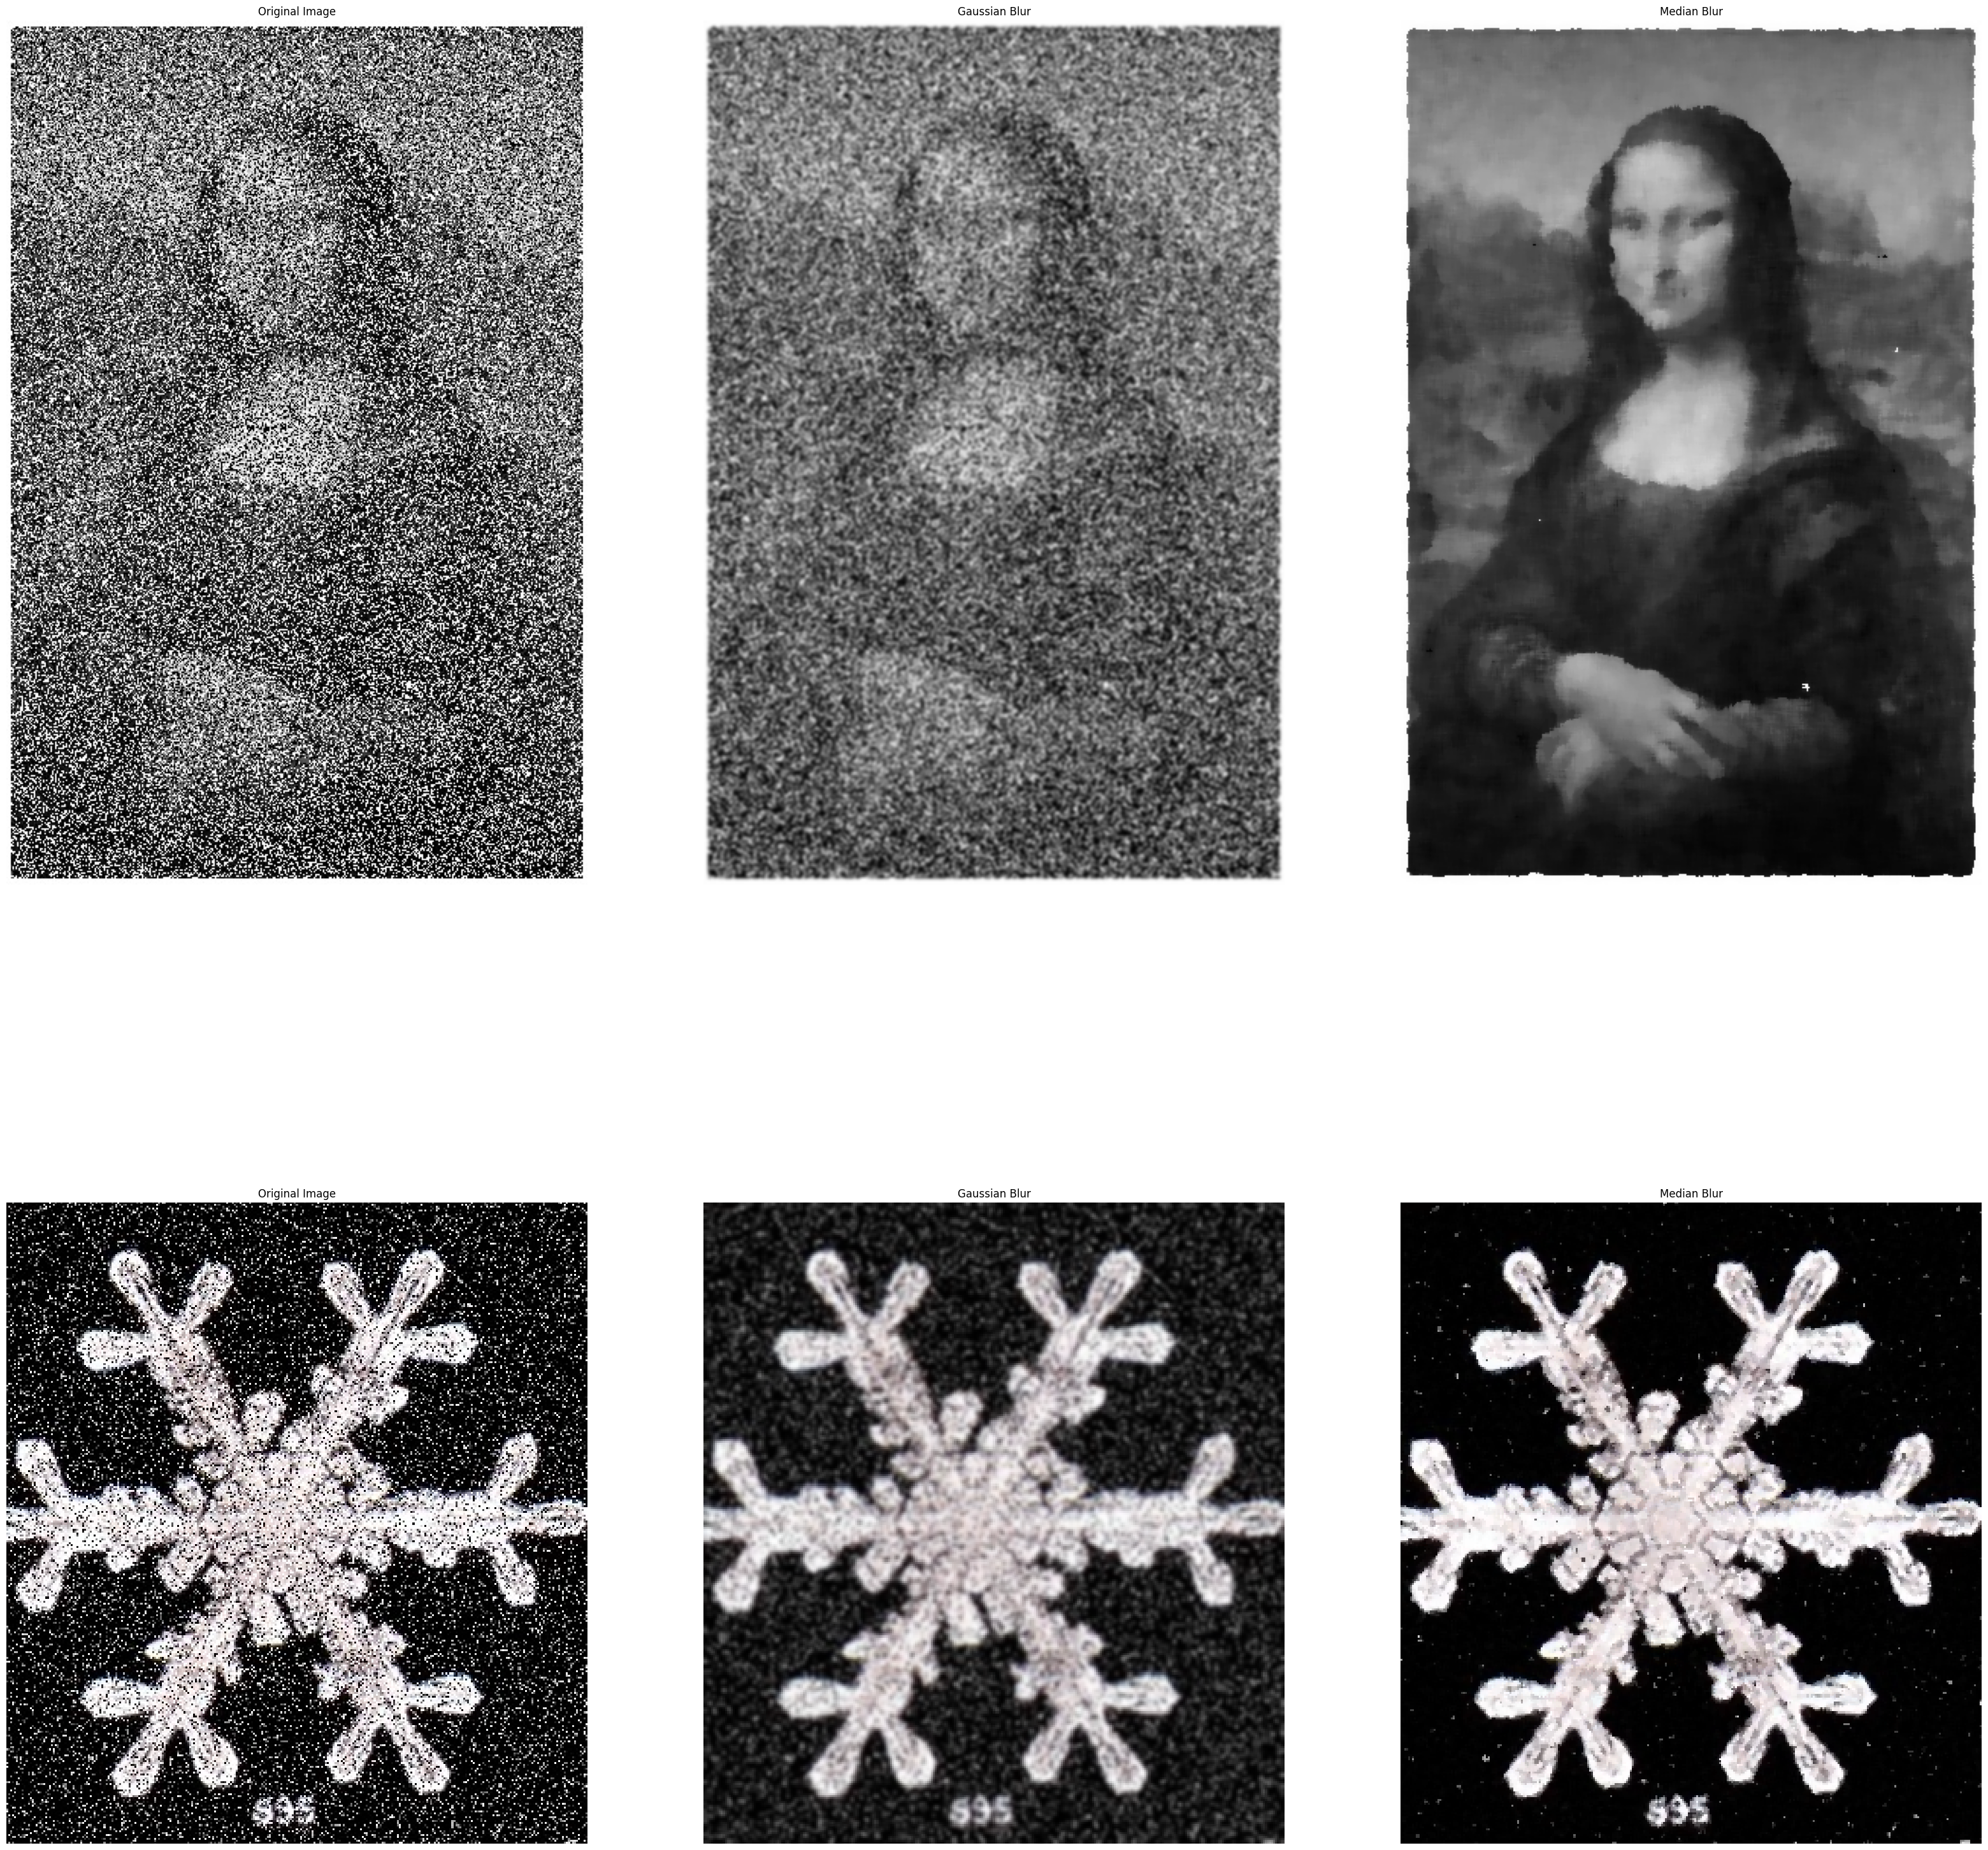

In [11]:
img1 = cv2.imread('data/images/mona_lisa.jpg')
img2 = cv2.imread('data/images/ice-flakes-microscopy-salt-and-pepper-noise.jpg')

img1_gaussian = cv2.GaussianBlur(img1, (5, 5), 0)
img2_gaussian = cv2.GaussianBlur(img2, (5, 5), 0)

img1_median = cv2.medianBlur(img1, 9)
img2_median = cv2.medianBlur(img2, 3)

plt.figure(figsize=(40, 40))
plt.subplot(231);plt.imshow(img1);plt.title('Original Image');plt.axis('off');
plt.subplot(232);plt.imshow(img1_gaussian);plt.title('Gaussian Blur');plt.axis('off');
plt.subplot(233);plt.imshow(img1_median);plt.title('Median Blur');plt.axis('off');
plt.subplot(234);plt.imshow(img2);plt.title('Original Image');plt.axis('off');
plt.subplot(235);plt.imshow(img2_gaussian);plt.title('Gaussian Blur');plt.axis('off');
plt.subplot(236);plt.imshow(img2_median);plt.title('Median Blur');plt.axis('off');
plt.show()

Text(0.5, 1.0, 'Bilateral blur Result')

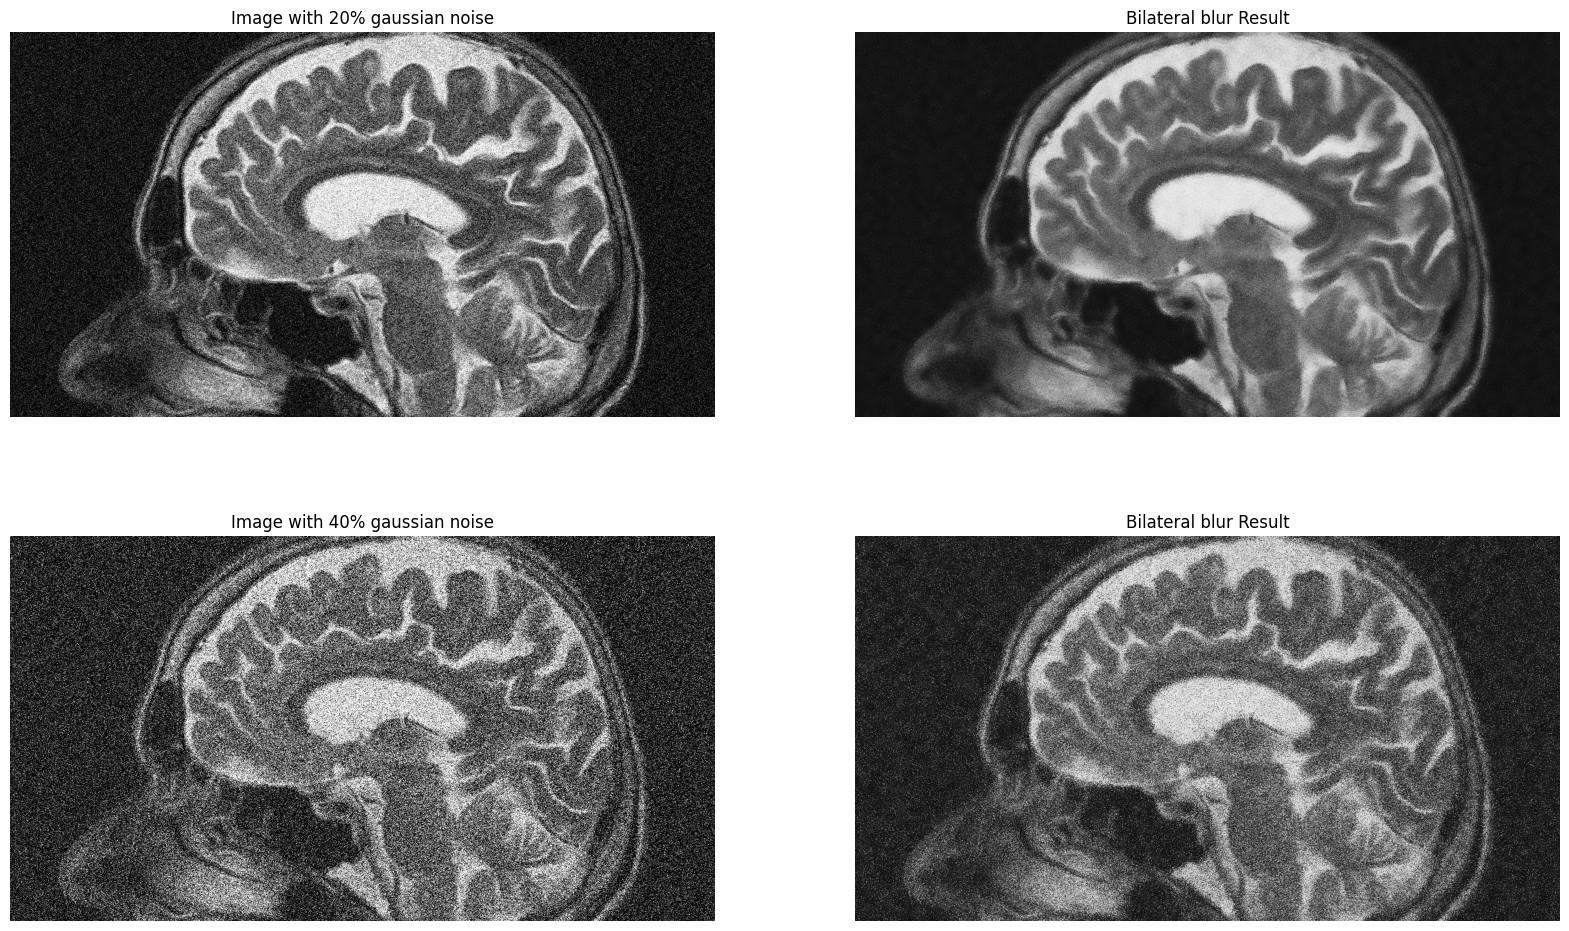

In [12]:
img1 = cv2.imread('data/images/mri-skull-20-percent-gaussian-noise.jpg')
img2 = cv2.imread('data/images/mri-skull-40-percent-gaussian-noise.jpg')

dia = 20

# Larger the value the distant colours will be mixed together
# to produce areas of semi equal colors.
sigmaColor = 200

sigmaSpace = 100

dst1 = cv2.bilateralFilter(img1, dia, sigmaColor, sigmaSpace)
dst2 = cv2.bilateralFilter(img2, dia, sigmaColor, sigmaSpace)

plt.figure(figsize = (20, 12))
plt.subplot(221); plt.axis('off'); plt.imshow(img1[:,:,::-1]); plt.title("Image with 20% gaussian noise")
plt.subplot(222); plt.axis('off'); plt.imshow(dst1[:,:,::-1]);   plt.title("Bilateral blur Result")
plt.subplot(223); plt.axis('off'); plt.imshow(img2[:,:,::-1]); plt.title("Image with 40% gaussian noise")
plt.subplot(224); plt.axis('off'); plt.imshow(dst2[:,:,::-1]);   plt.title("Bilateral blur Result")

Text(0.5, 1.0, 'Bilateral Filter')

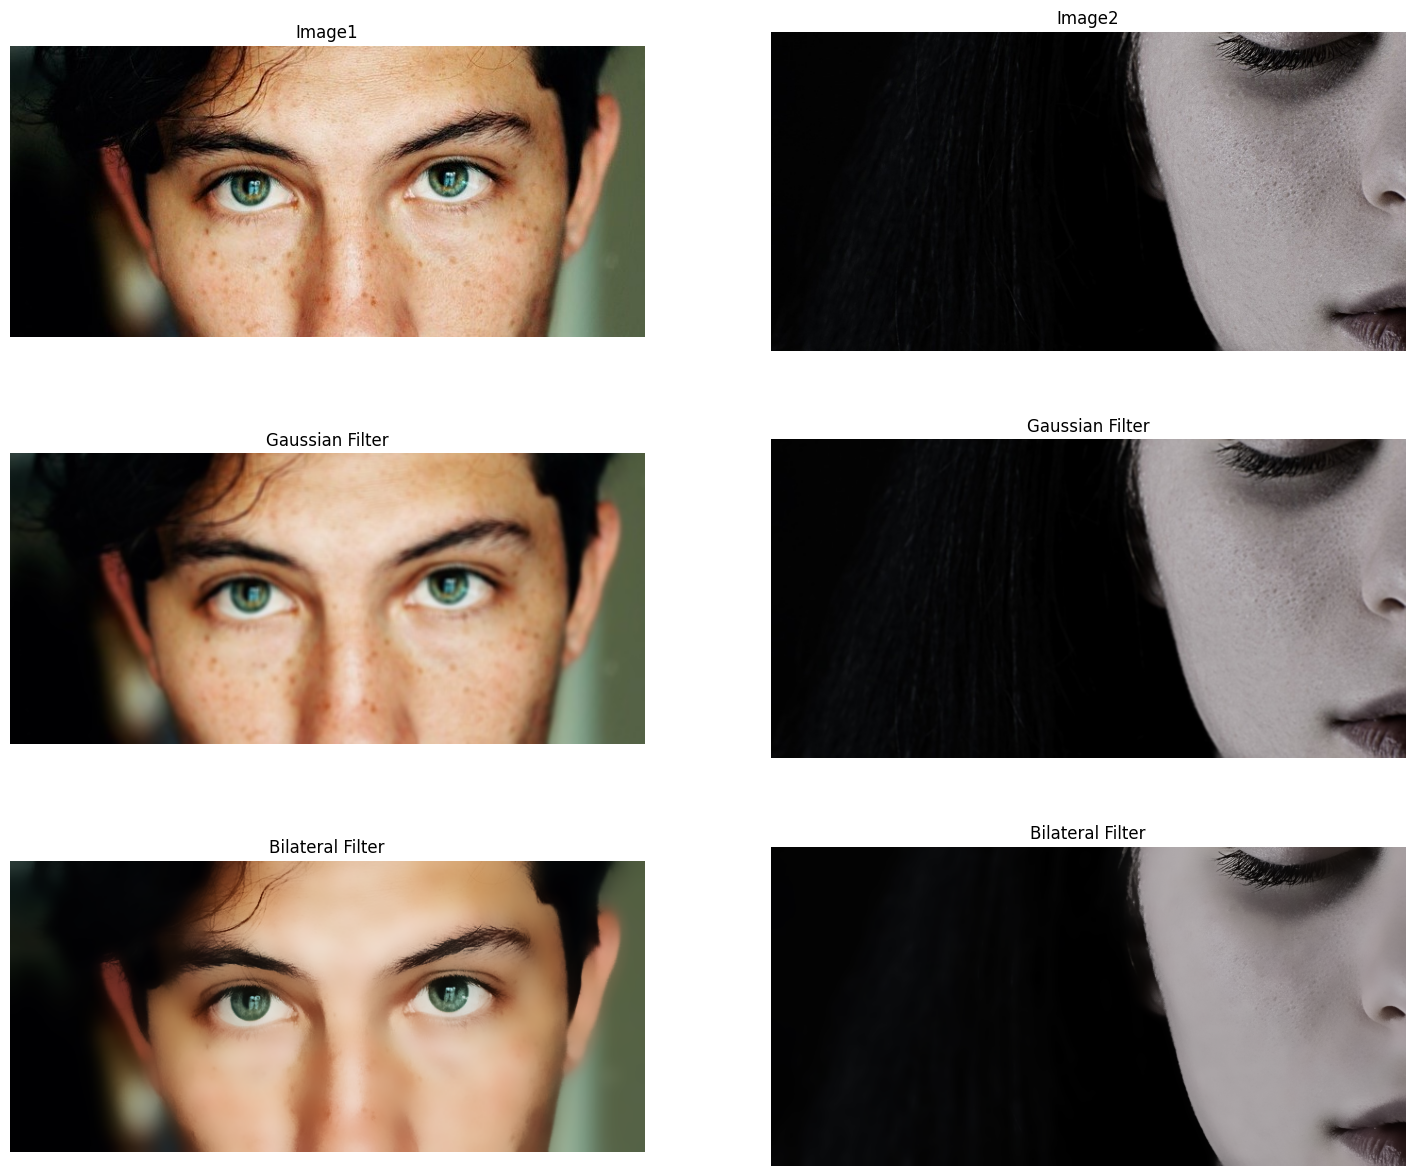

In [14]:
img1 = cv2.imread('data/images/face-original.jpg')
img2 = cv2.imread('data/images/girl-skin.jpg')

img1_gaussian = cv2.GaussianBlur(img1, (5,5), cv2.BORDER_DEFAULT)
img2_gaussian = cv2.GaussianBlur(img2, (5,5), cv2.BORDER_DEFAULT)

img1_bilateral = cv2.bilateralFilter(img1, d = 25, sigmaColor = 90, sigmaSpace = 40)
img2_bilateral = cv2.bilateralFilter(img2, d = 30, sigmaColor = 65, sigmaSpace = 15)

# Display.
plt.figure(figsize = (18, 15))
plt.subplot(321); plt.axis('off'); plt.imshow(img1[:,:,::-1]);plt.title('Image1')
plt.subplot(322); plt.axis('off'); plt.imshow(img2[:,:,::-1]);plt.title('Image2')
plt.subplot(323); plt.axis('off'); plt.imshow(img1_gaussian[:,:,::-1]);plt.title('Gaussian Filter')
plt.subplot(324); plt.axis('off'); plt.imshow(img2_gaussian[:,:,::-1]);plt.title('Gaussian Filter')
plt.subplot(325); plt.axis('off'); plt.imshow(img1_bilateral[:,:,::-1]);plt.title('Bilateral Filter')
plt.subplot(326); plt.axis('off'); plt.imshow(img2_bilateral[:,:,::-1]);plt.title('Bilateral Filter')

#### Image Inpainting

In [1]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
class Sketcher:
    def __init__(self, windowname, dests, colors_func):
        self.prev_pt = None
        self.windowname = windowname
        self.dests = dests
        self.colors_func = colors_func
        self.dirty = False
        self.show()
        cv2.setMouseCallback(self.windowname, self.on_mouse)

    def show(self):
        cv2.imshow(self.windowname, self.dests[0])
        cv2.imshow(self.windowname + " | mask", self.dests[1])

    def on_mouse(self, event, x, y, flags, param):
        pt = (x, y)
        if event == cv2.EVENT_LBUTTONDOWN:
            self.prev_pt = pt
        elif event == cv2.EVENT_LBUTTONUP:
            self.prev_pt = None
        
        if self.prev_pt and flags & cv2.EVENT_FLAG_LBUTTON:
            for dst, color in zip(self.dests, self.colors_func()):
                cv2.line(dst, self.prev_pt, pt, color, 5)
            self.dirty = True
            self.prev_pt = pt
            self.show()

In [7]:
img = cv2.imread('data/images/Lincoln.jpg')

img_mask = img.copy()

inpaintMask = np.zeros(img.shape[:2], dtype=np.uint8)

sketch = Sketcher("Image", [img_mask, inpaintMask], lambda: ((0, 255, 0), 255))

In [8]:
while True:
    ch = cv2.waitKey()
    if ch == 27:
        break
    if ch == ord('t'):
        t1t = time.time()
        res = cv2.inpaint(img_mask, inpaintMask, 3, cv2.INPAINT_TELEA)
        t2t = time.time()
        ttime = t2t - t1t
        cv2.imshow("Inpaint Output using Telea", res)
    if ch == ord('n'):
        t1t = time.time()
        res = cv2.inpaint(img_mask, inpaintMask, 3, cv2.INPAINT_NS)
        t2t = time.time()
        ntime = t2t - t1t
        cv2.imshow("Inpaint Output using Navier-Stokes", res)
    if ch == ord('r'):
        img_mask[:] = img
        inpaintMask[:] = 0
        sketch.show()

In [9]:
cv2.destroyAllWindows()

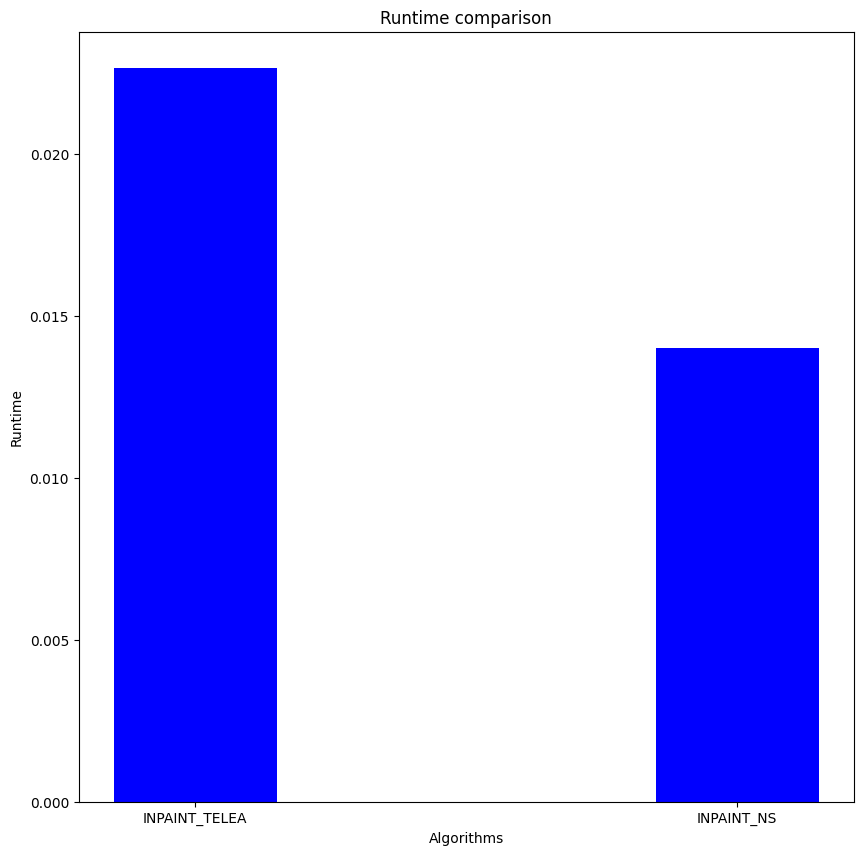

In [10]:
times = [ttime, ntime]
methods = ['INPAINT_TELEA', 'INPAINT_NS']

# Plot size
fig = plt.figure(figsize = (10, 10))
 
# Creating the stacked bar plot
plt.bar(methods, times, color ='blue', width = 0.3)
 
plt.xlabel('Algorithms')
plt.ylabel('Runtime')
plt.title('Runtime comparison')
plt.show()